# Bioprocess Model From VTT (2025)

This model aims to describe a growth system of *Pseudomonas putida* in different
set-ups. The model not only studies the microorganism’s growth dynamics
but also the consumption of a carbon source (substrate) and other nutrients
(chemical elements). Additionally, it examines the dynamics of gases that may
be used in the process, including both those in the gas phase of the system and
those dissolved in the liquid phase.

For further information, please check the [*BIOS_Pseudomonas_model.pdf*](../misc/BIOS_Pseudomonas_model.pdf) document associated with this notebook in the *misc* folder.

In [2]:
# Lorena Bioprocess Model — Modular ODEs with flexible fed modes
# Requirements: numpy, scipy
from bioprocess_utils import *
from ipywidgets import interact, FloatSlider

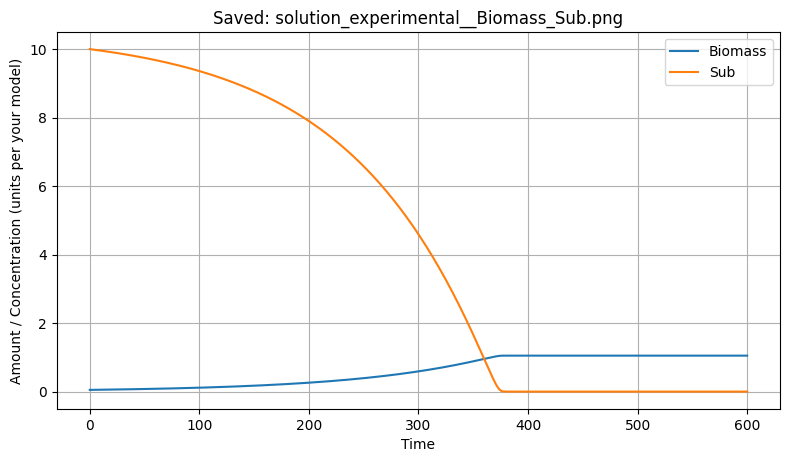

Inputs saved to: ./experimental_inputs
Solution files: {'npz': 'experimental_outputs/solution.npz', 'csv': 'experimental_outputs/solution.csv', 'params_json': 'experimental_outputs/solution.params.json', 'initials_json': 'experimental_outputs/solution.initials.json'}


In [18]:
# pipeline
params , inits = load_model_inputs("./experimental_inputs/ambr_run1_140323_13-18__R1__inputs.json")['params'],load_model_inputs("./experimental_inputs/ambr_run1_140323_13-18__R1__inputs.json")['initials']

# 0) Build a reproducible set of INPUTS
inputs = assemble_inputs(
    params   = params,
    initials = inits,
    mode_name ="batch",
    mode_consts={"Vf_const": 0.0, "Vs_const": 0.0, "VGasIn_const": 0.0, "VOffGas_const": 0.0},
    t_span=(0.0, 600.0),
    t_eval=None,             # or np.linspace(0, 600, 501)
    method="LSODA",
    rtol=1e-6,
    atol=1e-9
)

## 1) Save INPUTS only (so you can re-run later identically)
inputs_dir = "./experimental_inputs"
outputs_dir = "./experimental_outputs"
save_model_inputs(inputs, out_dir=inputs_dir, basename="inputs")

# 2) (At any later time) Reload those inputs
loaded = load_model_inputs(inputs_dir, basename="inputs")

# 3) Simulate from the loaded inputs (no surprises)
sol = run_from_inputs(loaded)

# 4) Save the numerical SOLUTION + metadata (CSV/NPZ/JSON)
written = save_solution(sol, loaded["params"], loaded["initials"],
                        out_dir=outputs_dir, basename="solution")

# 5) Plot a few series and save the figure
vars_to_show = ["Biomass", "Sub"]
plot_timeseries(
    sol,
    variables=vars_to_show,
    out_dir=outputs_dir,
    basename="solution_experimental__"+"_".join(vars_to_show),
    show=True,   # set False for headless runs
    save=True
)

print("Inputs saved to:", inputs_dir)
print("Solution files:", written)


In [16]:
# Tuning key parameters
def run(mu_max=0.0075, K_subs=0.005, K_L_a=2.0):
    # 0) Build a reproducible set of INPUTS
    inputs = assemble_inputs(
        params=params,
        initials=inits,
        mode_name="fed-batch",
        mode_consts={"Vf_const": 0.0, "Vs_const": 0.0, "VGasIn_const": 0.1, "VOffGas_const": 0.1},
        t_span=(0.0, 600.0),
        t_eval=None,             # or np.linspace(0, 600, 501)
        method="LSODA",
        rtol=1e-6,
        atol=1e-9
    )
    # 1) Updating the parameters to tune manually
    inputs["params"]["mu_max"]["values"][0]    = mu_max
    inputs["params"]["K_subs"]["values"][0]    = K_subs
    inputs["params"]["K_L_a"]["values"][0]     = K_L_a


    #display(inputs["params"]["T_Kelvin"])
    # 2) Simulate from the loaded inputs 
    sol = run_from_inputs(inputs)

    # 3) Plot a few series 
    vars_to_show = ["Biomass","Sub"]
    plot_timeseries(
        sol,
        variables=vars_to_show,
        out_dir = None,
        basename="solution"+"_".join(vars_to_show),
        show=True,   # set False for headless runs
        save=False
    )

mu_max_seed    = loaded["params"]["mu_max"]["values"][0]
K_subs_seed    = loaded["params"]["K_subs"]["values"][0]
K_L_a_seed     = loaded["params"]["K_L_a"]["values"][0]


In [19]:

interact(run,
         mu_max=FloatSlider(value=mu_max_seed, min=mu_max_seed/10, max=mu_max_seed*10, step=mu_max_seed/10, description='μmax'),
         K_subs=FloatSlider(value=K_subs_seed, min=K_subs_seed/10, max=K_subs_seed*10, step=K_subs_seed/10, description='Ks'),
         K_L_a=FloatSlider(value=K_L_a_seed, min=K_L_a_seed/10, max=K_L_a_seed*10, step=K_L_a_seed/10, description='KLa'),
         )


interactive(children=(FloatSlider(value=0.008333333333333333, description='μmax', max=0.08333333333333333, min…

<function __main__.run(mu_max=0.0075, K_subs=0.005, K_L_a=2.0)>

In [6]:
inputs["initials"]

{'Sub': {'values': [0.13], 'unit': 'mol'},
 'Biomass': {'values': [0.04267], 'unit': 'g'},
 'Ca': {'values': [0.0], 'unit': 'mol'},
 'Cl': {'values': [0.000173], 'unit': 'mol'},
 'Co': {'values': [8.405819516967989e-07], 'unit': 'mol'},
 'Cu': {'values': [5.865708131748498e-08], 'unit': 'mol'},
 'Fe': {'values': [1.798470580618242e-06], 'unit': 'mol'},
 'Mg': {'values': [0.0001622889229695627], 'unit': 'mol'},
 'Mo': {'values': [1.239887682707782e-07], 'unit': 'mol'},
 'Na': {'values': [0.009841767287091], 'unit': 'mol'},
 'Zn': {'values': [3.477547216397331e-07], 'unit': 'mol'},
 'K': {'values': [0.004408992875802], 'unit': 'mol'},
 'Ni': {'values': [8.414299934452604e-08], 'unit': 'mol'},
 'NH4': {'values': [0.006054221608728], 'unit': 'mol'},
 'P': {'values': [0.00863557426884131], 'unit': 'mol'},
 'S': {'values': [0.00319746255924881], 'unit': 'mol'},
 'CO2_l': {'values': [3.5053383749999997e-06], 'unit': 'mol'},
 'CO2_g': {'values': [0.0017180378517745538], 'unit': 'mol'},
 'O2_l'